In [39]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import plotly.express as px

In [40]:
#simulando o que ele puxa de utils.py
def apply_custom_style():
    """Configura o look-and-feel global do projeto."""
    px.defaults.template = "plotly_white"
    px.defaults.color_continuous_scale = "Viridis"
    plt.style.use('ggplot')

In [41]:
apply_custom_style()

In [42]:
df = pd.read_csv('data/processed/dados_projeto_limpos.csv')

df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce').astype('Int64')

In [43]:
## Pra criar uma função que filtre os Top N de alguma métrica, sem perder o histórico #de release_year, que é essencial para a análise de evolução temporal. Assim, podemos #focar nos modelos mais relevantes sem perder a visão do panorama geral.
#def top_n_history(df, y_col, x_col, group_col=None, n=10):
#    # Ordena o DataFrame por uma coluna de valor de interesse e pega os Top N:
#    top_n = df.sort_values(by=y_col, ascending=False).head(n)
#
#    #Filtra o dataframe original para manter o histórico de release_year dos Top N e #posteriormente agrupa os dados por outra coluna desejada (como por exemplo: #model_slug, provider, etc.) para facilitar a análise de evolução temporal pra cada #campo analisável:
#    if group_col:
#        filtered_df = df[df[group_col].isin(top_n[group_col])].groupby([x_col, #group_col])[y_col].mean().reset_index()
#    else:
#        filtered_df = df[df['model_slug'].isin(top_n['model_slug'])].groupby(x_col)#[y_col].mean().reset_index()
#
#
#    return filtered_df

def top_n_history(df, x_col, y_col, group_col=None, n=10):
    #df é o DataFrame original, y_col é a coluna de valor que queremos analisar, x_col é a coluna do eixo x, group_col é a coluna pela qual queremos agrupar (como model_slug ou provider) e n é o número de top que queremos manter.
    if not group_col:
        # Se group_col não for fornecido, não agrupamos e apenas pegamos os top n de y_col
        top_n = df.sort_values(by=y_col, ascending=False).head(n)
        return top_n[[x_col, y_col]]
    top_groups = df.groupby(group_col)[y_col].mean().nlargest(n).index
    filtered_df = df[df[group_col].isin(top_groups)]
    return filtered_df.groupby([x_col, group_col])[y_col].mean().reset_index()

#exemplo de uso:
#top_n_df = top_n_history(df, x_col='release_year', y_col='blended_cost_usd_per_1m', group_col='model_slug', n=10)
#ou
#top_n_df = top_n_history(df, x_col='release_year', y_col='blended_cost_usd_per_1m', group_col='provider', n=10)
#ou ainda 
#top_n_df = top_n_history(df, x_col='release_year', y_col='blended_cost_usd_per_1m', group_col='model_family', n=10)


## **Usando Seaborn**

In [44]:
#criar uma função de plotagem de linha com a biblioteca seaborn:
def plot_performance_line(data, x_col, y_col, title):

    """
    Plota um gráfico de linha para desempenho ao longo do tempo.

    Args:
        data (pd.DataFrame): DataFrame contendo os dados a serem plotados.
        x_col (str): Nome da coluna para o eixo x (geralmente data).
        y_col (str): Nome da coluna para o eixo y (geralmente métrica de desempenho).
        title (str): Título do gráfico.

    Returns:
        matplotlib.figure.Figure: Objeto da figura do gráfico.
    """
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=data, x=x_col, y=y_col, marker='o')
    plt.title(title)
    plt.xlabel(x_col.capitalize())
    plt.ylabel(y_col.capitalize())
    plt.xticks(rotation=45)
    plt.tight_layout()
    return plt.gcf()

In [45]:
def plot_performance_line(data, x_col, y_col, title=None, group_col=None, n=None):
    sns.set_theme(style="whitegrid")
    # Se n for fornecido, filtra os top n antes de plotar
    if n and group_col:
        top_groups = data.groupby(group_col)[y_col].mean().nlargest(n).index
        data = data[data[group_col].isin(top_groups)]
        data = data.groupby([x_col, group_col])[y_col].mean().reset_index()
    elif n:
        top_n = data.sort_values(by=y_col, ascending=False).head(n)
        data = top_n[[x_col, y_col]]
    

    plt.figure(figsize=(12, 6))
    
    # O segredo está aqui: o parâmetro hue recebe a coluna de categorias para diferenciar as linhas por cor
    sns.lineplot(data=data, x=x_col, y=y_col, hue=group_col, marker='o')
    
    plt.title(title)
    plt.xlabel(x_col.replace('_', ' ').capitalize())
    plt.ylabel(y_col.replace('_', ' ').capitalize())
    plt.xticks(rotation=45)
    plt.grid(True, which='both', linestyle='--', alpha=0.7)
    plt.legend(title=group_col.replace('_', ' ').capitalize())
    sns.move_legend(plt.gca(), "upper left", bbox_to_anchor=(1, 1))
    plt.tight_layout()

    return plt.gcf()

#Exemplo de uso:
#fig_line = plot_performance_line(data, 'release_year', 'intelligence_per_dollar', 'Inteligência por Dólar no tempo', group_col='model_slug', n=10)

In [46]:
#criar uma função de plotagem de barras com a biblioteca seaborn:
def plot_performance_bar(data, x_col, y_col, title):
    """
    Plota um gráfico de barras para desempenho por categoria.

    Args:
        data (pd.DataFrame): DataFrame contendo os dados a serem plotados.
        x_col (str): Nome da coluna para o eixo x (geralmente categoria).
        y_col (str): Nome da coluna para o eixo y (geralmente métrica de desempenho).
        title (str): Título do gráfico.

    Returns:
        matplotlib.figure.Figure: Objeto da figura do gráfico.
    """
    plt.figure(figsize=(10, 6))
    sns.barplot(data=data, x=x_col, y=y_col)
    plt.title(title)
    plt.xlabel(x_col.title())
    plt.ylabel(y_col.title())
    plt.xticks(rotation=45)
    plt.tight_layout()
    return plt.gcf()

In [47]:
#criar uma função de plotagem de dispersão com a biblioteca seaborn:
def plot_performance_scatter(data, x_col, y_col, title):
    """
    Plota um gráfico de dispersão para desempenho por categoria.

    Args:
        data (pd.DataFrame): DataFrame contendo os dados a serem plotados.
        x_col (str): Nome da coluna para o eixo x (geralmente categoria).
        y_col (str): Nome da coluna para o eixo y (geralmente métrica de desempenho).
        title (str): Título do gráfico.

    Returns:
        matplotlib.figure.Figure: Objeto da figura do gráfico.
    """
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=data, x=x_col, y=y_col)
    plt.title(title)
    plt.xlabel(x_col.capitalize())
    plt.ylabel(y_col.capitalize())
    plt.xticks(rotation=45)
    plt.tight_layout()
    return plt.gcf()


In [48]:
#criar uma função de plotagem de área com a biblioteca seaborn:
def plot_performance_area(data, x_col, y_col, title):
    """
    Plota um gráfico de área para desempenho ao longo do tempo.

    Args:
        data (pd.DataFrame): DataFrame contendo os dados a serem plotados.
        x_col (str): Nome da coluna para o eixo x (geralmente data).
        y_col (str): Nome da coluna para o eixo y (geralmente métrica de desempenho).
        title (str): Título do gráfico.

    Returns:
        matplotlib.figure.Figure: Objeto da figura do gráfico.
    """
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=data, x=x_col, y=y_col, marker='o')
    plt.fill_between(data[x_col], data[y_col], alpha=0.3)
    plt.title(title)
    plt.xlabel(x_col.capitalize())
    plt.ylabel(y_col.capitalize())
    plt.xticks(rotation=45)
    plt.tight_layout()
    return plt.gcf()

In [49]:
#criar uma função de plotagem de rosca com a biblioteca seaborn:
def plot_performance_donut(data, x_col, y_col, title):
    """
    Plota um gráfico de rosca para desempenho por categoria.

    Args:
        data (pd.DataFrame): DataFrame contendo os dados a serem plotados.
        x_col (str): Nome da coluna para as categorias.
        y_col (str): Nome da coluna para os valores.
        title (str): Título do gráfico.

    Returns:
        matplotlib.figure.Figure: Objeto da figura do gráfico.
    """
    plt.figure(figsize=(8, 8))
    plt.pie(data[y_col], labels=data[x_col], autopct='%1.1f%%', startangle=140)
    plt.title(title)
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)
    plt.tight_layout()
    return fig

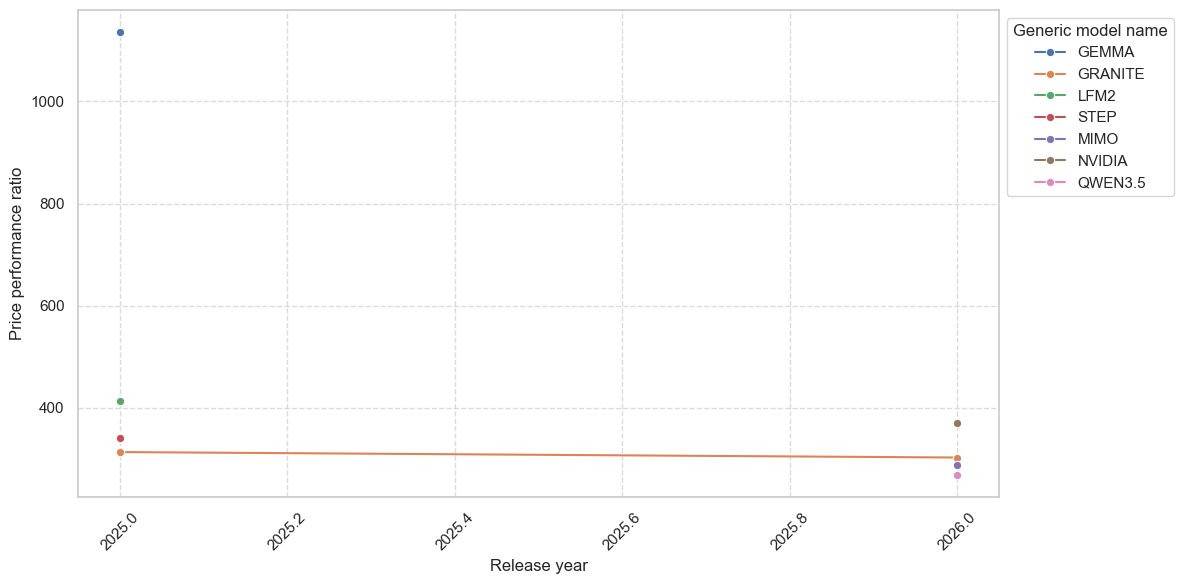

In [50]:
line_price_performance = plot_performance_line(df, 'release_year', 'price_performance_ratio', title=None, group_col='generic_model_name', n=10)







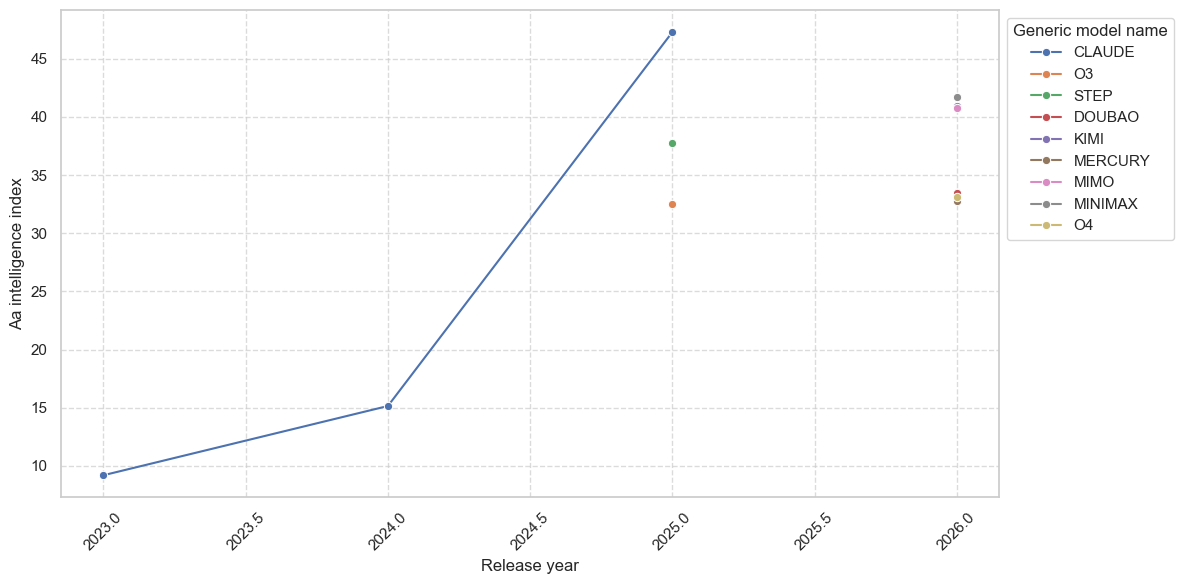

In [51]:
line_intelligence = plot_performance_line(df, 'release_year', 'aa_intelligence_index', title=None, group_col='generic_model_name', n=10)

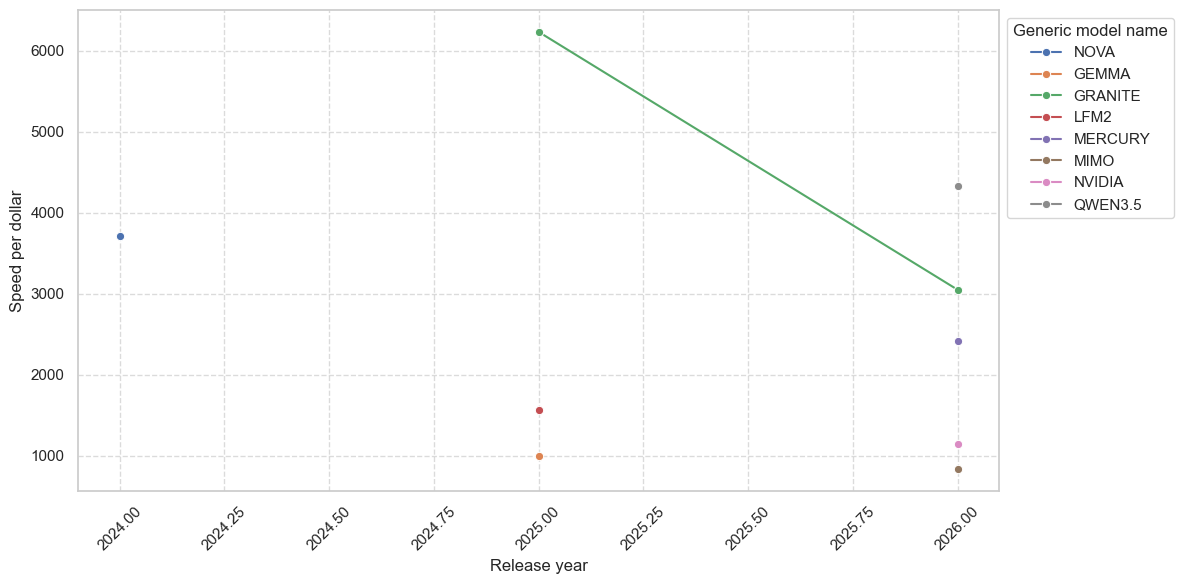

In [52]:
line_speed_dollar = plot_performance_line(df, 'release_year', 'speed_per_dollar', title=None, group_col='generic_model_name', n=10)

## **Usando Plotly**

In [53]:
#agora pra tentar fazer um gráfico interativo com a biblioteca plotly com múltiplas linhas, usando a mesma lógica de filtrar os top n por uma métrica e depois plotar a evolução temporal pra cada um desses top n, diferenciando por cor:
def plot_performance_line_interactive(data, x_col, y_col, title=None, group_col=None, n=None):
    # Se n for fornecido, filtra os top n antes de plotar
    if n and group_col:
        top_groups = data.groupby(group_col)[y_col].mean().nlargest(n).index
        data = data[data[group_col].isin(top_groups)]
        data = data.groupby([x_col, group_col])[y_col].mean().reset_index()
    elif n:
        top_n = data.sort_values(by=y_col, ascending=False).head(n)
        data = top_n[[x_col, y_col]]
    
    fig = px.line(data, x=x_col, y=y_col, color=group_col, markers=True, title=title)
    fig.update_xaxes(tickformat="d", rangeslider_visible=True) # Formata o eixo x para mostrar apenas os anos como inteiros
    fig.update_layout(xaxis_title=x_col.title().replace('_', ' '),
                      yaxis_title=y_col.title().replace('_', ' '),
                      legend_title=group_col.title().replace('_', ' '))
    plt.tight_layout()
    return fig


In [54]:
def plot_performance_barh_interactive(data, x_col, y_col, title=None, group_col=None, n=None, calculate='sum'):
    if calculate not in ('mean', 'sum'):
        raise ValueError("calculate deve ser 'mean' ou 'sum'")

    # Agrupa os valores por x e, se fornecido, por grupo.
    if group_col:
        data = data.groupby([x_col, group_col], dropna=False)[y_col].agg(calculate).reset_index()
    else:
        data = data.groupby(x_col, dropna=False)[y_col].agg(calculate).reset_index()

    if n and group_col:
        top_groups = data.groupby(group_col)[y_col].mean().nlargest(n).index
        data = data[data[group_col].isin(top_groups)]
    elif n:
        top_groups = data.groupby(x_col)[y_col].mean().nlargest(n).index
        data = data.sort_values(by=y_col, ascending=True).head(n)

    fig = px.bar(data, x=y_col, y=x_col, color=group_col, title=title, orientation='h')

    fig.update_layout(
        xaxis_title=y_col.title().replace('_', ' '),
        yaxis_title=x_col.title().replace('_', ' ')
    )
    if group_col:
        fig.update_layout(legend_title=group_col.title().replace('_', ' '))

    try:
        fig.update_yaxes(tickformat="d", rangeslider_visible=True)
    except Exception:
        pass
    return fig

In [55]:
def plot_performance_bar_interactive(data, x_col, y_col, title=None, group_col=None, n=None, calculate='sum'):
    if calculate not in ('mean', 'sum'):
        raise ValueError("calculate deve ser 'mean' ou 'sum'")

    # Agrupa os valores por x e, se fornecido, por grupo.
    if group_col:
        data = data.groupby([x_col, group_col], dropna=False)[y_col].agg(calculate).reset_index()
    else:
        data = data.groupby(x_col, dropna=False)[y_col].agg(calculate).reset_index()

    if n and group_col:
        top_groups = data.groupby(group_col)[y_col].mean().nlargest(n).index
        data = data[data[group_col].isin(top_groups)]
    elif n:
        top_groups = data.groupby(x_col)[y_col].mean().nlargest(n).index
        data = data.sort_values(by=y_col, ascending=True).head(n)

    fig = px.bar(data, x=x_col, y=y_col, color=group_col, title=title)

    fig.update_layout(
        xaxis_title=x_col.title().replace('_', ' '),
        yaxis_title=y_col.title().replace('_', ' ')
    )
    if group_col:
        fig.update_layout(legend_title=group_col.title().replace('_', ' '))

    try:
        fig.update_xaxes(tickformat="d", rangeslider_visible=True)
    except Exception:
        pass
    return fig

In [56]:
plot_performance_line_interactive(df, 'release_year', 'aa_intelligence_index', title='Intelligence Index Over Time', group_col='generic_model_name', n=20)

<Figure size 640x480 with 0 Axes>

In [57]:
plot_performance_barh_interactive(df, 'clean_model_name', 'intelligence_per_dollar', title='Intelligence Index per model', n=20, calculate='mean')

In [58]:
plot_performance_bar_interactive(df, 'is_open_source', 'intelligence_per_dollar', title='Open Source X Propietary comparison - Intelligence Index', n=20, calculate='mean')

In [59]:
#creating a correlation graph with plotly:
def plot_correlation_heatmap(data, cols, title=None):
    corr = data[cols].corr()
    fig = px.imshow(
        corr,
        text_auto=True,
        aspect="auto",
        title=title,
        color_continuous_scale='RdBu',
        zmin=-1,
        zmax=1
    )
    fig.update_layout(xaxis_title="Métricas", yaxis_title="Métricas")
    # paleta de cores do azul pro vermelho, passando por branco no meio
    fig.update_traces(colorbar_title='Correlação')
    # atualizar nomes de eixo de forma consistente
    tick_labels = [col.replace('_', ' ').title() for col in cols]
    tick_vals = list(range(len(cols)))
    fig.update_xaxes(tickvals=tick_vals, ticktext=tick_labels)
    fig.update_yaxes(tickvals=tick_vals, ticktext=tick_labels)
    plt.tight_layout()
    
    return fig

#exemplo de uso:
#plot_correlation_heatmap(df, ['aa_intelligence_index', 'price_performance_ratio', 'speed_per_dollar', 'intelligence_per_dollar'], title='Correlação entre Métricas de Desempenho')

In [60]:
plot_correlation_heatmap(df, ['release_year', 'aa_intelligence_index', 'time_to_first_answer_s','blended_cost_usd_per_1m', 'price_performance_ratio', ], title='Correlação entre Métricas de Desempenho e lançamento')

<Figure size 640x480 with 0 Axes>

In [98]:
#creating a scatter plot with plotly:
def plot_scatter_interactive(data, x_col, y_col, title=None, group_col=None, n=None, filter=False):
    """Plota um gráfico de dispersão interativo usando Plotly.
    args:
        data (pd.DataFrame): DataFrame contendo os dados a serem plotados.
        x_col (str): Nome da coluna para o eixo x.
        y_col (str): Nome da coluna para o eixo y.
        title (str, opcional): Título do gráfico. Padrão é None.
        group_col (str, opcional): Nome da coluna para agrupar por cor. Padrão é None.
        n (int, opcional): Número de top grupos a serem plotados. Padrão é None (todos os grupos).
        filter (bool, opcional): Se True, adiciona um filtro por ano de lançamento (release_year) usando um slider. Padrão é False.
    returns:
        plotly.graph_objs._figure.Figure: Objeto da figura do gráfico de dispersão.
    """

    # Garantir que a coluna 'release_year' seja do tipo numérico para evitar problemas no filtro
    data=data.copy().dropna(subset=['release_year'])

    # Se n for fornecido, filtra os top n antes de plotar
    if group_col and n:
        top_groups = data.groupby(group_col)[y_col].mean().nlargest(n).index
        data = data[data[group_col].isin(top_groups)]
    elif n:
        data = data.sort_values(by=y_col, ascending=False).head(n)

    # Para garantir que as categorias sejam ordenadas de forma consistente, criamos um dicionário de ordens de categoria baseado na média de y_col para cada grupo, ordenado de forma decrescente. Isso ajuda a manter uma ordem lógica nas legendas e cores do gráfico.
    category_orders = {}
    if group_col:
        group_order = data.groupby(group_col)[y_col].mean().sort_values(ascending=False).index.tolist()
        category_orders[group_col] = group_order
    # Agora, ao criar o gráfico de dispersão, passamos o parâmetro category_orders para garantir que as categorias sejam ordenadas de forma consistente com a média de y_col. Isso é especialmente útil para gráficos de dispersão onde a cor ou o agrupamento é baseado em categorias, garantindo que a legenda e as cores sejam apresentadas de forma lógica e fácil de interpretar.
    fig = px.scatter(
        data,
        x=x_col,
        y=y_col,
        color=group_col,
        title=title,
        category_orders=category_orders,
        labels={
            x_col: x_col.replace('_', ' ').title(),
            y_col: y_col.replace('_', ' ').title()
        },
    )

    # Configurações adicionais para melhorar a aparência do gráfico
    fig.update_traces(marker=dict(size=8, opacity=0.8))
    if group_col:
        fig.update_layout(
            legend_title=group_col.replace('_', ' ').title(),
            legend_traceorder='normal'
        )

    # Se filter for True e a coluna 'release_year' estiver presente, adiciona um slider para filtrar os dados por ano de lançamento
    if filter and 'release_year' in data.columns:
        # Ordena os anos de lançamento e cria um botão para cada ano
        years = sorted(data['release_year'].dropna().astype(int).unique())
        buttons = []
        for year in years:
            if group_col:
                x_vals = []
                y_vals = []
                for trace in fig.data: # Itera sobre cada traço (grupo) no gráfico
                    mask = (
                        (data[group_col] == trace.name) & # Filtra os dados para o grupo atual
                        (data['release_year'].astype(int) == year) # Filtra os dados para o ano atual
                    )
                    x_vals.append(data.loc[mask, x_col].tolist()) # Adiciona os valores de x para o grupo e ano atuais
                    y_vals.append(data.loc[mask, y_col].tolist()) # Adiciona os valores de y para o grupo e ano atuais
            else:
                mask = data['release_year'].astype(int) == year
                x_vals = [data.loc[mask, x_col].tolist()]
                y_vals = [data.loc[mask, y_col].tolist()]
            # Adição do botão para filtrar os dados por ano de lançamento
            buttons.append(dict(
                label=str(year),
                method='update', #O método 'update' é usado para atualizar os dados do gráfico com base no filtro aplicado.
                args=[
                    {'x': x_vals, 'y': y_vals}, #Atualiza os dados do gráfico com os valores filtrados para o ano selecionado.
                    {'title': f"{title or ''} - {year}"} # Atualiza o título do gráfico com o ano selecionado.
                ]
            ))

        # Adiciona um botão para mostrar todos os dados
        fig.update_layout(
            updatemenus=[dict(
                active=len(buttons) - 1,
                buttons=buttons,
                x=-0.1,
                #y=1.20,
                xanchor='right',
                yanchor='top'
            )]
        )
    plt.tight_layout()
    return fig

In [99]:
plot_scatter_interactive(df, 'blended_cost_usd_per_1m', 'aa_intelligence_index', group_col='provider', n=20, filter=True, title='Intelligence Index vs Cost per 1M Tokens with Year Filter')

<Figure size 640x480 with 0 Axes>

In [100]:
plot_scatter_interactive(df, 'blended_cost_usd_per_1m', 'aa_coding_index', group_col='clean_model_name', n=20, filter=True, title='Intelligence Index vs Cost per 1M Tokens with Year Filter')

<Figure size 640x480 with 0 Axes>